# Lecture

## The sequence to sequence problem

Generative model:
$$
p(y|x) \to \max_y
$$

- Statistical approach:
  $$
  p(y|x) \propto p(x|y) p(y)
  $$
    
  Discriminative model is sometimes easier to learn, but still very tricky.
- Neural approach:
  $$
  p(y|x) = p(y_t | y_{t-1}, y_{t-2}, \ldots, y_1, x) p(y_{t-1} | y_{t-2}, \ldots, y_1, x) \ldots p(y_1 | x) 
  $$

  Each term is a neural network. Better performance, less effort.

## Example: Neural Machine Translation

<img src="seq2seq.png" width=800px/>

## Problems of sequence to sequence models

<table>
    <tr>
        <td><img src="seq2seq.png" width=700px/></td>
        <td>
            <ul>
                <li>Bottleneck</li>
                <li>Hard to keep relevant context in longer texts</li>
            </ul>
        </td>
    </tr>
</table>

## Solution: attention

<!-- Formulas + key/value + what is QKV in different tasks -->

<table>
    <tr>
        <td><img src="attention.png" width=400px/></td>
        <td>
            <ul>
                <li>Encoder RNN produces encoder hidden states ${ \color{blue} h_1, h_2, \ldots, h_N } \in \mathbb{R}^h$</li>
                <li>Decoder RNN has hidden state ${ \color{green} s_t } \in \mathbb{R}^h$ at step $t$</li>
                <li>Attention scores for step $t$ are computed as inner product between encoder and decoder hidden states:
                    $$
                    { \color{orange} e_{ti} } = { \color{green} s_t^\top } { \color{blue} h_i } \in \mathbb{R}
                    $$
                </li>
                <li>Attention distribution is obtained via softmax:
                    $$
                    { \color{orange} \alpha_t } = \operatorname{softmax}({ \color{orange} e_t }) \in \mathbb{R}^N
                    $$
                </li>
                <li>The final output of attention is a sum of encoder hidden states weighted by the attention distribution:
                    $$
                    { \color{yellow} a_t } = \sum_{i=1}^N { \color{orange} \alpha_{ti} } { \color{blue} h_i } \in \mathbb{R}^h
                    $$
                </li>
                <li>Then ${ \color{yellow} a_t }$ is used together with $\color {green} s_t$ for decoding $\color{red} y_t$</li>
            </ul>
        </td>
    </tr>
</table>

## Attention

<table>
    <tr>
        <td><img src="attention.png" width=400px/></td>
        <td><img src="attention-2.png" width=500px/></td>
    </tr>
</table>

## Attention advantages

- Significantly improves performance
- Solves the bottleneck problem
- Solves vanishing gradients problem
- Provides interpretability

## Key-value interpretation

Denote
- $q_i$ the query to a database
- $k_j$ the keys in a database
- $v_j$ the values in a database

Then to retrieve a value, we
1. Calculate relevant entries using inner product $e_j = q_i^\top k_j$
2. Normalize the scores with softmax $\alpha = \operatorname{softmax}(e)$
3. Extract value equal to weighted sum of relevant values $a_i = \sum_{i=1}^N \alpha_j v_j$

$$
A = \operatorname{softmax}(QK^\top / {\color{red} \sqrt{d_k}}) V
$$

## Transformer

<table>
    <tr>
        <td>
            <ul>
                <li>Completely drop RNN</li>
                <li>There is an encoder and a decoder</li>
                <li>Make many rounds of self-attention</li>
            </ul>
        </td>
        <td><img src="transformer.svg" width=500px/></td>
    </tr>
</table>

## Self-attention

<table>
    <tr>
        <td>
            <ul>
                <li>$A = \operatorname{softmax}(QK^\top / \sqrt{d_k}) V$</li>
                <li>$Q = XW^Q$</li>
                <li>$K = XW^K$</li>
                <li>$V = XW^V$</li>
            </ul>
            <br>
            All the same data!
        </td>
        <td><img src="transformer.svg" width=600px/></td>
        <td><img src="self-attention.png" width=150px/></td>
    </tr>
</table>

## Multi-head attention

<table>
    <tr>
        <td>
            $$
                \operatorname{MultiHead}(Q, K, V) = \operatorname{concat}(\operatorname{head}_1, \operatorname{head_2}, \ldots, \operatorname{head}_h) W^O
            $$
            where
            $$
                \operatorname{head}_i = \operatorname{Attention}(QW_i^Q, KW_i^K, VW_i^V)
            $$
        </td>
        <td><img src="self-attention.png" width=200px/></td>
        <td><img src="multihead-attention.png" width=300px/></td>
    </tr>
</table>

## Layer Normalization

<table>
    <tr>
        <td>
            <ul>
                <li>Speeds up training</li>
                <li>Similar effect to BatchNormalization</li>
                <li>But can be used with batch size 1</li>
            </ul>
        </td>
        <td><img src="transformer.svg" width=500px/></td>
    </tr>
</table>

## Position encoding

- Without positional encoding there is no sequential information
- Not one-hot for varied sequence length
- But can be used with batch size 1

<img src="positional-encoding.png" width=800px/></td>

## Transformer derivatives

| Model | Examples | Tasks | Training |
| :-: | :-: | :-: | :-: |
| Encoder only | ALBERT, BERT, DistilBERT, ELECTRA, RoBERTa | Sentence classification, named entity recognition, extractive question answering | Masked language modeling |
| Decoder only | CTRL, GPT, GPT-2, Transformer XL | Text generation | Next token prediction |
| Encoder-decoder | BART, T5, Marian, mBART | Summarization, translation, generative question answering | Denoising |

## Problems of transformers

- Costs: GPT-3 train cost is estimated to be 10-50 billion USD
- Data: Llama 3 was trained on over 15T tokens, that's roughly 10 trillion words
- Complexity of self-attention
  $$
    \operatorname{Attention} = \operatorname{softmax}(QK^\top / \sqrt{d_k}) V
  $$

# Webinar

<table>
    <tr>
        <td><img src="attention.png" width=400px/></td>
        <td>
            <ul>
                <li>Encoder RNN produces encoder hidden states ${ \color{blue} h_1, h_2, \ldots, h_N } \in \mathbb{R}^h$</li>
                <li>Decoder RNN has hidden state ${ \color{green} s_t } \in \mathbb{R}^h$ at step $t$</li>
                <li>Attention scores for step $t$ are computed as inner product between encoder and decoder hidden states:
                    $$
                    { \color{orange} e_{ti} } = { \color{green} s_t^\top } { \color{blue} h_i } \in \mathbb{R}
                    $$
                </li>
                <li>Attention distribution is obtained via softmax:
                    $$
                    { \color{orange} \alpha_t } = \operatorname{softmax}({ \color{orange} e_t }) \in \mathbb{R}^N
                    $$
                </li>
                <li>The final output of attention is a sum of encoder hidden states weighted by the attention distribution:
                    $$
                    { \color{yellow} a_t } = \sum_{i=1}^N { \color{orange} \alpha_{ti} } { \color{blue} h_i } \in \mathbb{R}^h
                    $$
                </li>
                <li>Then ${ \color{yellow} a_t }$ is used together with $\color {green} s_t$ for decoding $\color{red} y_t$</li>
                <li>
                    Matrix form:
                    $$
                    A = \operatorname{softmax}(QK^\top / {\color{red} \sqrt{d_k}}) V
                    $$
                </li>
            </ul>
        </td>
    </tr>
</table>

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm

## Similarity scores

Attention scores for step $t$ are computed as inner product between queries and keys:
$$
e_{ti} = q_t^\top k_i
$$
$$
E = Q K^\top
$$

In [2]:
torch.manual_seed(0)
d = 64
t, k = 10, 8
batch_size = 3
query = torch.rand(10, d)
query = query.repeat(batch_size, 1, 1)

key = torch.rand(8, d)
key = key.repeat(batch_size, 1, 1)

In [3]:
def scalar_similarity_coefficient(x, y, d):
    return torch.dot(x,y) / np.sqrt(d)

In [4]:
def compute_coefficient_matrix(query, key, d):
    return torch.matmul(query, key.transpose(-1, -2)) / np.sqrt(d)

In [5]:
coefficient_matrix = compute_coefficient_matrix(query, key, d)

second_query = query[0, 2]
third_key = key[0, 3]

assert torch.allclose(coefficient_matrix[0, 2, 3], scalar_similarity_coefficient(second_query, third_key, d))
assert torch.allclose(coefficient_matrix[0], coefficient_matrix[1])
assert torch.Size([batch_size, t, k]) == coefficient_matrix.shape

## Attention distribution

After we obtain the scores, we need to covert them to a distribution using softmax:
$$
\alpha_t = \operatorname{softmax}(e_t)
$$
$$
\alpha = \operatorname{softmax}(E)
$$

In [6]:
torch.manual_seed(2)
d = 64
t,k = 10, 8
batch_size = 3
query = torch.rand(batch_size, 10, d)
key = torch.rand(batch_size, 8, d)

In [7]:
def compute_attention_matrix(query, key, d):
    coefficient_matrix = compute_coefficient_matrix(query, key, d)
    attention_matrix = torch.softmax(coefficient_matrix, dim=-1)
    return attention_matrix

In [8]:
A = compute_attention_matrix(query, key, d)

assert np.allclose((A.sum(axis=-1) - 1).sum().numpy(), 0, atol=1e-6)
assert torch.all(A >= 0.0)

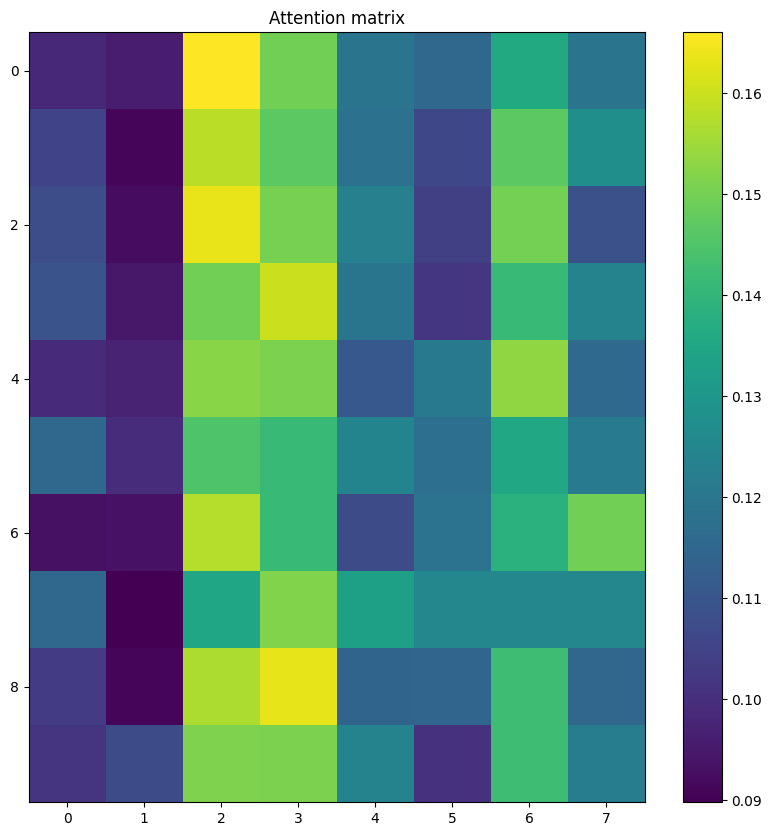

In [9]:
plt.figure(figsize=(10,10))
plt.title('Attention matrix')
plt.imshow(A[0])
plt.colorbar();

## Attention

The last step to obtain attention is to пуе a sum of encoder hidden states weighted by the attention distribution:
$$
a_t = \sum_{i=1}^N \alpha_{ti} v_i
$$
$$
A = \alpha V,
$$

In [10]:
torch.manual_seed(6)
d = 64
t, k = 10, 8
batch_size = 3
query = torch.rand(batch_size, t, d)
key = torch.rand(batch_size, k, d)
value = torch.rand(batch_size, k, d)

In [11]:
def attention(query, key, value, d):
    coefficient_matrix = compute_coefficient_matrix(query, key, d)
    attention_matrix = torch.softmax(coefficient_matrix, dim=-1)
    out = torch.matmul(attention_matrix, value)
    return attention_matrix, out

In [12]:
A, out = attention(query, key, value, d)
assert out.shape == query.shape
assert torch.allclose(out.sum(), torch.tensor(973.154541015625))

## Attention layer

In real applications we additionally use a linear projection operator before computing attention. This way the model can view the data in the most efficient way:
- $A = \operatorname{softmax}(Q'K'^\top / \sqrt{d_k}) V'$
- $Q' = QW^Q$
- $K' = KW^K$
- $V' = VW^V$

In [13]:
d = 32
t, k = 10, 8
batch_size = 3
query = torch.rand(batch_size, t, d)
key = torch.rand(batch_size, k, d)
value = torch.rand(batch_size, k, d)

In [14]:
class AttentionLayer(torch.nn.Module):
    def __init__(self, d):
        super().__init__()
        # self.q_layer = # TODO: Trainable projection layer
        # self.k_layer = # TODO: Trainable projection layer
        # self.v_layer = # TODO: Trainable projection layer
        self.q_layer = torch.nn.Linear(d, d)
        self.k_layer = torch.nn.Linear(d, d, bias=False)
        self.v_layer = torch.nn.Linear(d, d)
        self.d = d

    def forward(self, query, key, value):
        self.q_proj = self.q_layer(query)
        self.k_proj = self.k_layer(key)
        self.v_proj = self.v_layer(value)
        self.A, out = attention(self.q_proj, self.k_proj, self.v_proj, self.d)
        return out

In [15]:
att_layer_out = AttentionLayer(32)(query, key, value)
assert att_layer_out.shape == query.shape
assert not torch.allclose(attention(query, key, value, d)[1], att_layer_out)

## Self-attention

Often, especially in NLP, attention is used simply as a feature generator. In this case, it makes sense to apply it to the same data:
- $A = \operatorname{softmax}(QK^\top / \sqrt{d_k}) V$
- $Q = XW^Q$
- $K = XW^K$
- $V = XW^V$

In [16]:
d = 32
t = 10
batch_size = 3
x = torch.rand(batch_size, t, d)

att_layer_out = AttentionLayer(32)(x, x, x)

## Practice

In [17]:
def generate_dataset(seq_len, sample_count, target_elements_per_seq=3):
    marker = torch.zeros(sample_count, seq_len)
    for i in range(sample_count):
        pos = np.random.permutation(np.arange(seq_len))[:target_elements_per_seq]
        marker[i][pos] = 1.

    scaler = 10
    number = torch.rand(sample_count, seq_len) * scaler - scaler / 2
    y = (number * marker).sum(axis=1)
    x = torch.stack((number, marker), dim=-1)
    return x, y

In [18]:
X, y = generate_dataset(20, 10_000)

In [19]:
X[0], y[0]

(tensor([[-1.4347,  0.0000],
         [ 1.2226,  0.0000],
         [-3.2325,  1.0000],
         [ 2.2884,  0.0000],
         [ 2.7109,  0.0000],
         [-4.7629,  0.0000],
         [ 4.9267,  0.0000],
         [-1.8437,  0.0000],
         [-4.1342,  0.0000],
         [ 1.8623,  0.0000],
         [-3.4110,  0.0000],
         [-2.0196,  0.0000],
         [ 0.3168,  0.0000],
         [-4.0927,  0.0000],
         [-3.2945,  0.0000],
         [-3.5540,  0.0000],
         [ 2.9108,  0.0000],
         [-3.7476,  1.0000],
         [ 1.7920,  0.0000],
         [ 4.7178,  1.0000]]),
 tensor(-2.2623))

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [28]:
from torch.utils.data import TensorDataset, DataLoader

In [27]:
ds_train = TensorDataset(X_train, y_train)
ds_test = TensorDataset(X_test, y_test)

In [29]:
dl_train = DataLoader(ds_train, batch_size=64)
dl_test = DataLoader(ds_test, batch_size=64)

In [30]:
import torch.nn as nn

In [32]:
import torch.nn.functional as F

In [73]:
class AttentionSum(nn.Module):
    def __init__(self, d):
        super().__init__()

        self.query = nn.Parameter(torch.rand(1, 1, d))
        self.attention = AttentionLayer(d)
        self.embedding = nn.Linear(2, d)
        self.linear = nn.Linear(d, 1)

    def forward(self, x):
        x = self.embedding(x)
        out = self.attention(self.query, x, x)  # (batch_size, 1, hidden_size)
        out = out.squeeze(1)  # (batch_size, hidden_size)
        return self.linear(out).squeeze()

In [74]:
model = AttentionSum(32)

In [75]:
from torch.optim import Adam

In [76]:
optimizer = Adam(model.parameters(), lr=1e-3, weight_decay=1e-6)

In [77]:
lossf = nn.MSELoss()

In [78]:
epochs = 10

In [79]:
for epoch in range(1, epochs+1):
    model.train()

    losses = []
    for batch, y in dl_train:
        loss_value = lossf(model(batch), y)
        loss_value.backward()

        optimizer.step()
        optimizer.zero_grad()

        losses.append(loss_value.item())

    model.eval()
    val_losses = []
    with torch.no_grad():
        for batch, y in dl_test:
            loss_value = lossf(model(batch), y)
            val_losses.append(loss_value.item())


    print(
        f"[{epoch}/10] Training loss: {np.mean(losses):.4f}\t Validation loss: {np.mean(val_losses):.4f}"
    )

[1/10] Training loss: 10.8497	 Validation loss: 0.0510
[2/10] Training loss: 0.0337	 Validation loss: 0.0273
[3/10] Training loss: 0.0151	 Validation loss: 0.0104
[4/10] Training loss: 0.0086	 Validation loss: 0.0055
[5/10] Training loss: 0.0080	 Validation loss: 0.0041
[6/10] Training loss: 0.0055	 Validation loss: 0.0051
[7/10] Training loss: 0.0054	 Validation loss: 0.0033
[8/10] Training loss: 0.0073	 Validation loss: 0.0081
[9/10] Training loss: 0.0062	 Validation loss: 0.0067
[10/10] Training loss: 0.0095	 Validation loss: 0.0102


In [80]:
model.eval()

AttentionSum(
  (attention): AttentionLayer(
    (q_layer): Linear(in_features=32, out_features=32, bias=True)
    (k_layer): Linear(in_features=32, out_features=32, bias=False)
    (v_layer): Linear(in_features=32, out_features=32, bias=True)
  )
  (embedding): Linear(in_features=2, out_features=32, bias=True)
  (linear): Linear(in_features=32, out_features=1, bias=True)
)

In [97]:
i = np.random.randint(len(X_test))

In [98]:
xx = X_test[i]
xx_numpy = xx.numpy()

In [99]:
print(xx_numpy[:, 0])

[ 0.17554283  3.0774126   3.533328    2.8971357  -3.7920964  -4.3150415
  4.5463104   3.9223404   1.4721861   1.4830761   4.053993    2.8878903
 -0.75384235 -1.595592   -0.5051813   1.2516403   0.07707596  2.2222786
 -0.46315622 -0.62813187]


In [100]:
print(xx_numpy[:, 1])

[0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0.]


In [101]:
print(xx_numpy[xx_numpy[:, 1].astype(bool), 0].sum())
print(y_test[i])

1.1282344
tensor(1.1282)


In [102]:
print(model(xx))

tensor(1.1433, grad_fn=<SqueezeBackward0>)


In [109]:
model.attention.A.detach().numpy().flatten()

array([0.0009852 , 0.00097406, 0.00097232, 0.00097475, 0.00100064,
       0.0010027 , 0.00096847, 0.00097084, 0.32636002, 0.00098017,
       0.00097034, 0.00097478, 0.0009888 , 0.330308  , 0.00098783,
       0.32664227, 0.00098558, 0.00097733, 0.00098767, 0.00098831],
      dtype=float32)

In [107]:
import seaborn as sns

<Axes: >

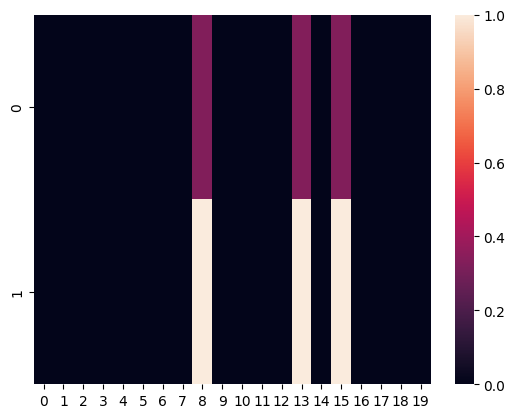

In [108]:
sns.heatmap(
    np.vstack([
        model.attention.A.detach().numpy().flatten(),
        xx_numpy[:, 1],
    ])
)